# Anatomical Variation Colormap

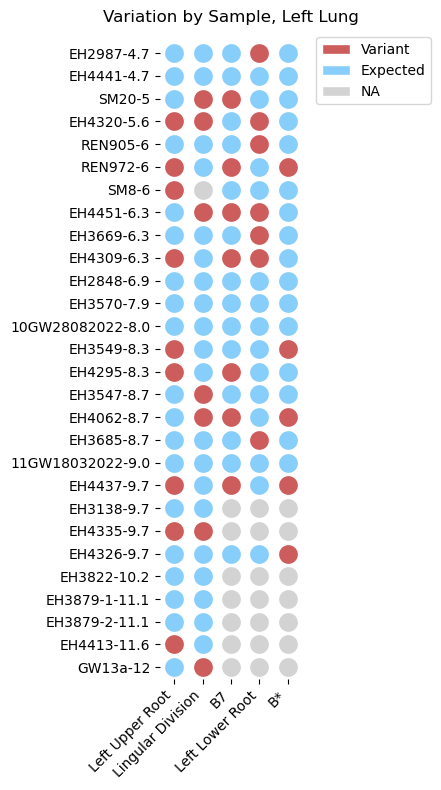

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load CSV file
csv_file_path = r'C:\Users\ADMINS1\Documents\GitHub\3D_human_lung_development\anatomical_variation.csv'  # Replace with the actual file path or name
df = pd.read_csv(csv_file_path)
df.columns = df.columns.str.strip()

# Sort by Dev Age
df = df.sort_values(by='Dev Age').reset_index(drop=True)

# Define variation columns
variation_cols = df.columns[2:]

# Setup figure
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust height for spacing

# Map categorical values to colors
color_map = {
    'Yes': 'indianred',
    'No': 'lightskyblue',
    'X': 'lightgray'
}

# Adjust spacing
row_spacing = 2
n_rows = len(df)
n_cols = len(variation_cols)

# Plot (youngest at top)
for i, sample in enumerate(df['Sample']):
    y = (n_rows - 1 - i) * row_spacing  # Reverse the row order manually
    for j, col in enumerate(variation_cols):
        value = df.at[i, col]
        color = color_map.get(value, 'gray')
        ax.scatter(j, y, s=210, color=color, edgecolors='white')

# Set ticks
ax.set_xticks(range(n_cols))
ax.set_xticklabels(variation_cols, rotation=45, ha='right')
ax.set_yticks([(n_rows - 1 - i) * row_spacing for i in range(n_rows)])
ax.set_yticklabels(df['Sample'])

# Set limits with padding
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-1, row_spacing * n_rows)

# Set aspect ratio to squeeze columns
ax.set_aspect(0.4)

# Clean plot style
ax.grid(False)
ax.set_frame_on(False)

# Add legend
legend_elements = [
    Patch(facecolor='indianred', edgecolor='white', label='Variant'),
    Patch(facecolor='lightskyblue', edgecolor='white', label='Expected'),
    Patch(facecolor='lightgray', edgecolor='white', label='NA')
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Variation by Sample, Left Lung')

# Get the folder where the CSV is located and save the plot as a PNG file there
save_path = os.path.join(os.path.dirname(csv_file_path), 'variation_plot_Left.png')
plt.tight_layout()
plt.savefig(save_path)
plt.show()

In [29]:
import pandas as pd
from itertools import combinations
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Load and prepare data
df = pd.read_csv(r'C:\Users\ADMINS1\Documents\GitHub\3D_human_lung_development\anatomical_variation.csv')  # Replace with the actual file path or name
df.columns = df.columns.str.strip()
variation_cols = df.columns[2:]

# Convert to binary (Yes=1, No/X=0)
binary_df = df[variation_cols].replace({'Yes': 1, 'No': 0, 'X': 0})

# Store results
results = []

# Test all unique pairs of variation types
for var1, var2 in combinations(variation_cols, 2):
    # Contingency table
    table = pd.crosstab(binary_df[var1], binary_df[var2])
    
    # Must be 2x2 for Fisher's exact test
    if table.shape == (2, 2):
        oddsratio, pval = fisher_exact(table)
        results.append((var1, var2, pval))

# Correct for multiple comparisons
pvals = [r[2] for r in results]
_, corrected_pvals, _, _ = multipletests(pvals, method='fdr_bh')

# Combine and filter significant results
significant = []
for (var1, var2, pval), corrected in zip(results, corrected_pvals):
    if corrected < 0.05:
        significant.append((var1, var2, pval, corrected))

# Output
if significant:
    print("Significant associations between variation types (FDR < 0.05):")
    for var1, var2, pval, corrected in significant:
        print(f"{var1} ↔ {var2}: p = {pval:.4f}, FDR-corrected = {corrected:.4f}")
else:
    print("None")

None
